In [ ]:
import sys
import os
from pathlib import Path

project_root = Path().resolve().parent
sys.path.append(str(project_root))

import pandas as pd
import numpy as np

import seaborn as sns
sns.set_style('darkgrid')

from src.Market import Market

In [2]:
from joblib import dump, load

market = load(project_root / "results/market_simulation.joblib")

In [235]:
import src.utils
from importlib import reload
reload(src.utils)
from src.utils import make_scenario, generate_scenarios

In [58]:
scenario, r_m, last_r, last_vol = make_scenario(100, "weekly", market, 500, return_last=True)

In [448]:
N = 20 # n_assets
T = 10 # n_timeperiods - the amount the model sees ahead
K = 100 # n_scenarios

freq = 'weekly'
rf = market.rf

n_steps = 52
n_simulations = 50

In [22]:
scenarios = generate_scenarios(K, T, N, 'weekly', market, 500)

## MPC

In [455]:
import src.MPCController
from importlib import reload
reload(src.MPCController)
from src.MPCController import MPCController

from src.utils import simulate_target_weight_portfolio

In [456]:
controller = MPCController(K, T, N, risk_free=rf, risk=0.2, trade=0.005, risk_type='semi_variance')

In [457]:
controller.is_QP_and_DPP()

(True, True)

In [453]:
from tqdm.notebook import tqdm
import time

for i in tqdm(range(5), desc='Outer'):
    for j in tqdm(range(10), desc='Inner'):
        time.sleep(.2)

Outer:   0%|          | 0/5 [00:00<?, ?it/s]

Inner:   0%|          | 0/10 [00:00<?, ?it/s]

Inner:   0%|          | 0/10 [00:00<?, ?it/s]

Inner:   0%|          | 0/10 [00:00<?, ?it/s]

Inner:   0%|          | 0/10 [00:00<?, ?it/s]

Inner:   0%|          | 0/10 [00:00<?, ?it/s]

In [458]:
from tqdm.notebook import tqdm

import warnings

with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=UserWarning)

    x_init = [100] + [0 for _ in range(N)]

    MPC_sims = np.zeros((n_simulations, n_steps+1, N+1)) # + initial value
    market_sims = np.zeros((n_simulations, n_steps+1))
    eq_sims = np.zeros((n_simulations, n_steps+1, N+1))

    for i in tqdm(range(n_simulations), desc='Simulations'):
        # NOTE: lasts are always daily for market, and market return is too
        actual_traj, market_return, last_r_m, last_vol =\
            make_scenario(n_steps, freq, market, 500, return_last=True)

        MPC_sim = [x_init]

        for step in tqdm(range(n_steps), desc=f'simulation {i+1}'):
            if step == 0:
                scenarios = generate_scenarios(K ,T, N, freq, market, burn=500)
            else:
                scenarios = generate_scenarios(K ,T, N, freq, market, burn=0, 
                                                init_value=last_r_m.iloc[step-1], 
                                                init_vol=last_vol.iloc[step-1])
            
            controller.update_parameters(scenarios, MPC_sim[-1])
            stats = controller.solve()
            u0 = controller.control()

            x_next = (MPC_sim[-1] + u0) * np.hstack([1+rf, 1+actual_traj.iloc[step]])

            MPC_sim.append(x_next)

        MPC_sims[i] = np.array(MPC_sim)
        market_sims[i] = np.exp(np.concat([[0], market_return])).cumprod() * 100
        eq_sims[i] = simulate_target_weight_portfolio(x_init, [0] + [1/N for _ in range(N)], rf, actual_traj.T, trading_cost=0.005)

Simulations:   0%|          | 0/50 [00:00<?, ?it/s]

simulation 1:   0%|          | 0/52 [00:00<?, ?it/s]

simulation 2:   0%|          | 0/52 [00:00<?, ?it/s]

simulation 3:   0%|          | 0/52 [00:00<?, ?it/s]

simulation 4:   0%|          | 0/52 [00:00<?, ?it/s]

...

simulation 46:   0%|          | 0/52 [00:00<?, ?it/s]

simulation 47:   0%|          | 0/52 [00:00<?, ?it/s]

simulation 48:   0%|          | 0/52 [00:00<?, ?it/s]

simulation 49:   0%|          | 0/52 [00:00<?, ?it/s]

simulation 50:   0%|          | 0/52 [00:00<?, ?it/s]

## Results

In [459]:
from joblib import dump
dump(MPC_sims, project_root / "results/MPC_sims.joblib")
dump(market_sims, project_root / "results/market_sims.joblib")
dump(eq_sims, project_root / "results/eq_sims.joblib")

['C:\\Users\\lovas\\Desktop\\Szakdoga\\code\\results\\eq_sims.joblib']

In [460]:
market_sims = pd.DataFrame(market_sims)
MPC_sims = pd.DataFrame(MPC_sims.sum(axis=2))
eq_sims = pd.DataFrame(eq_sims.sum(axis=2))

<Axes: >

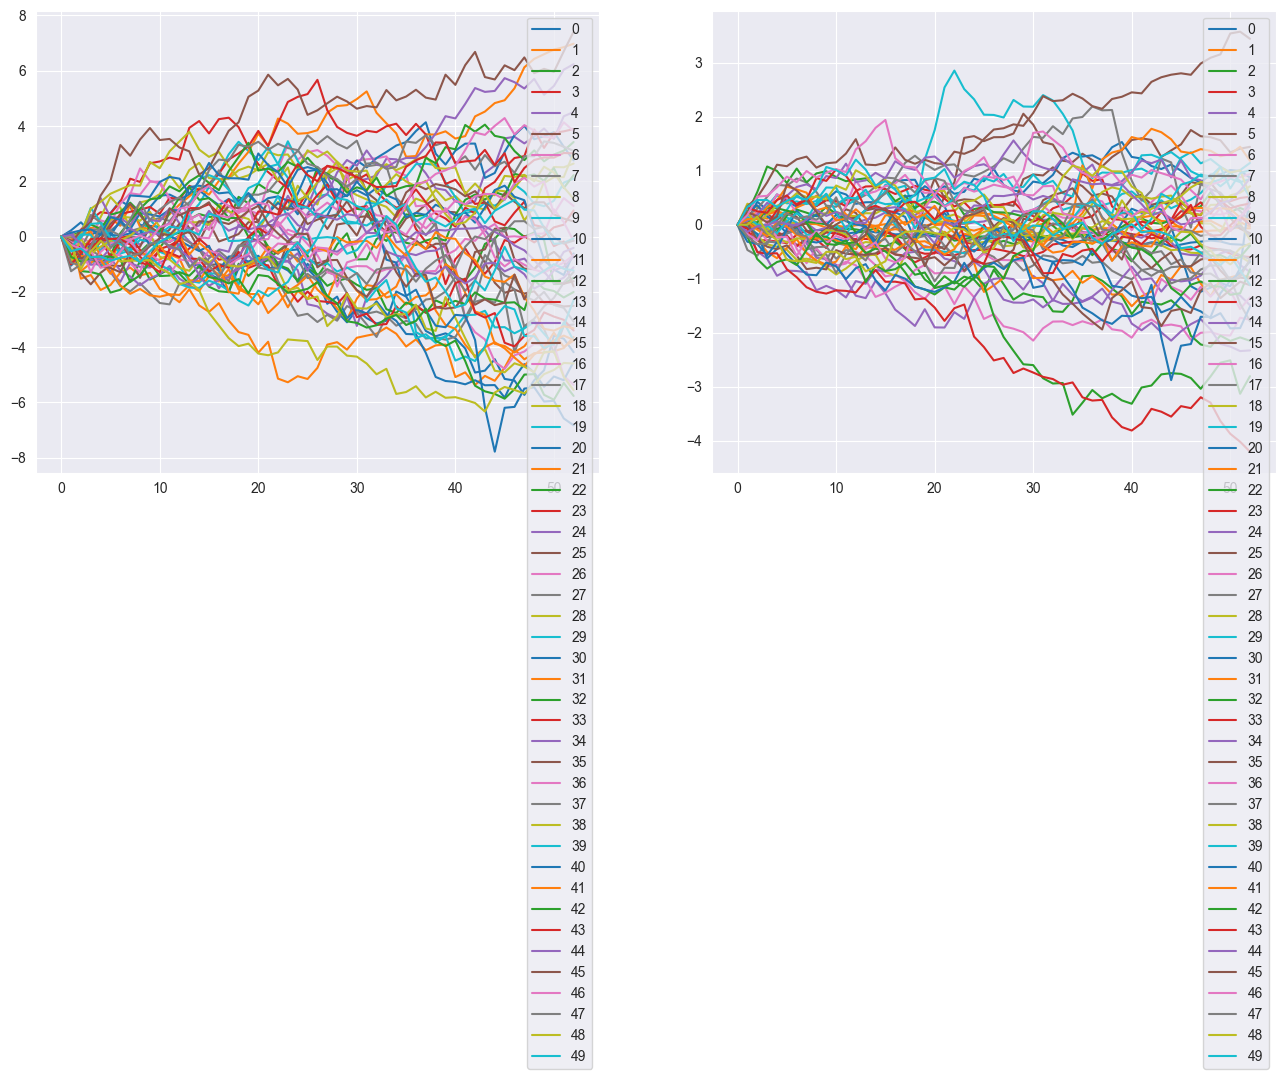

In [461]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize= (16,6))

(MPC_sims.T - market_sims.T).plot(ax=ax[0])
(MPC_sims.T - eq_sims.T).plot(ax=ax[1])

In [462]:
def plot_simulations(dfs:list[pd.DataFrame], labels):
    fig, ax = plt.subplots(1, len(labels), figsize=(16, 6))
    
    low = min([df.min().min() for df in dfs])
    high = max([df.max().max() for df in dfs])

    low = 0.99*low if low > 0 else 1.01*low
    high = 1.01*high if high > 0 else 0.99*high

    for i, (label, df) in enumerate(zip(labels, dfs)):    
        ax[i].plot(df.mean(), label='mean')
        ax[i].fill_between(df.columns, df.mean() - df.std(), df.mean() + df.std(), alpha=0.2, label="mean ± std")
        ax[i].plot(df.max(), label = 'max', linestyle="--", color='green')
        ax[i].plot(df.min(), label = 'min', linestyle="--", color="red")

        ax[i].set_title(f"{label}")
        ax[i].set_ylim(0.9*low, 1.1*high)

        ax[i].legend()


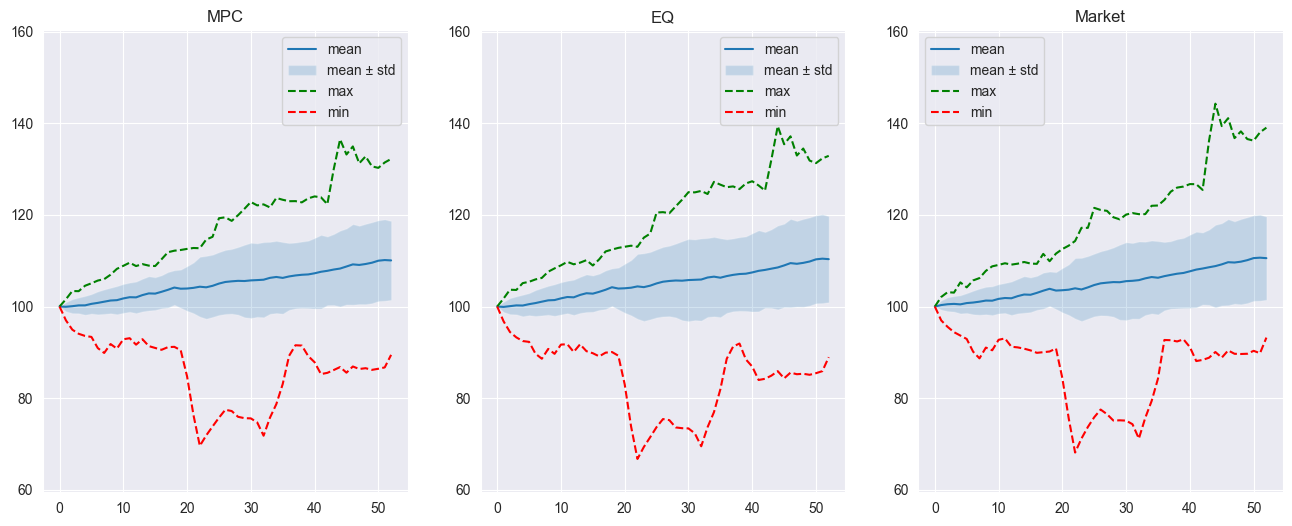

In [463]:
plot_simulations([MPC_sims, eq_sims, market_sims], labels=['MPC', 'EQ', 'Market'])

In [464]:
def compute_returns(dfs:list[pd.DataFrame], names:list[str]):
    returns = {}

    for name, df in zip(names, dfs):
        returns[name] = (df.T / df.T.shift(1)) - 1
        returns[name].dropna(inplace=True)
    return returns

In [465]:
returns = compute_returns([MPC_sims, eq_sims, market_sims], names=['MPC', 'EQ', 'Market'])

In [466]:
def compute_metrics(returns):
    metrics = pd.DataFrame(index=returns.keys())

    mean_returns = {}
    std_r = {}

    mean_sharpe_ratios = {}
    mean_sortino_ratios = {}

    for name, ret in returns.items():
        mean_returns[name] = np.mean(ret)
        std_r[name] = ret.std().mean()

        mean_sharpe_ratios[name] = ((ret.mean() - rf) / ret.std()).mean()
        mean_sortino_ratios[name] = ((ret.mean() - rf) / np.maximum(0, -ret).std()).mean()


    metrics['Expected return'] = mean_returns
    metrics['Mean std'] = std_r

    metrics['Mean Sharpe Ratio'] = mean_sharpe_ratios
    metrics['Mean Sortino Ratio'] = mean_sortino_ratios


    return metrics


In [467]:
metrics = compute_metrics(returns)
metrics

,Expected return,Mean std,Mean Sharpe Ratio,Mean Sortino Ratio
MPC,0.001861,0.010705,0.195260,0.419308
EQ,0.001914,0.011907,0.180829,0.389281
Market,0.001954,0.011272,0.198840,0.439704
